# Imports

In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

# Model And Data Loading

In [ ]:
# model = joblib.load('../models/random_forest.pkl')
model = joblib.load('../models/best_model_v1.pkl')

X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_test = pd.read_parquet('../data/processed/y_test.parquet').squeeze()

ValueError: <class 'numpy.random._mt19937.MT19937'> is not a known BitGenerator module.

# Metrics

In [ ]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, pred))
print('ROC-AUC: ', roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.61      0.27      0.38      1834
           1       0.68      0.90      0.78      3166

    accuracy                           0.67      5000
   macro avg       0.65      0.59      0.58      5000
weighted avg       0.66      0.67      0.63      5000

ROC-AUC:  0.6930055641628508


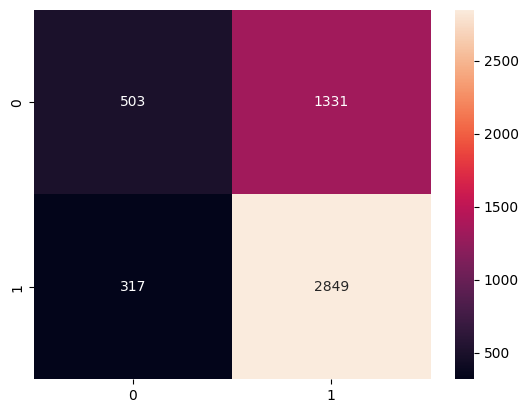

In [ ]:
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d')
plt.show()

# Feature Importance

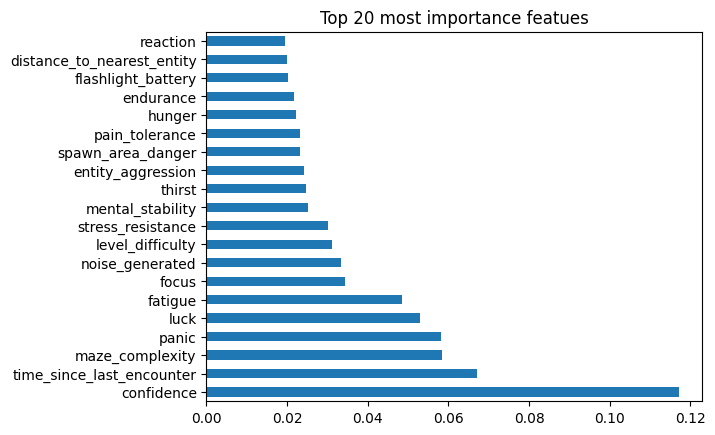

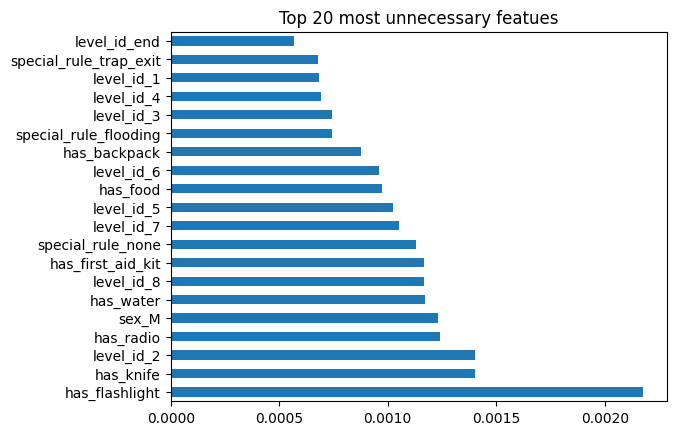

In [ ]:
importances = pd.Series(model.feature_importances_, index=X_test.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title('Top 20 most importance featues')
plt.show()
importances.sort_values(ascending=False).tail(20).plot(kind='barh')
plt.title('Top 20 most unnecessary featues')
plt.show()